# Data blocking

In this notebook I inspect the output of one strain-stress simulation with MACE potential, inspect the output, demonstrate data-blocking, and fix the analysis pipeline.

In [1]:
!which python

/home/gabrielecolombo/Thesis/PROJECT/.venv/bin/python


In [2]:
import numpy as np
import pandas as pd

from lammps_logfile import read_log

import matplotlib.pyplot as plt

from ase.io import write
import os

## Load data

Load and check everything is as expected.

## Structural analysis

I have to find a good order parameter to determine phase transition

In [3]:
from ase.io import Trajectory

In [5]:
import subprocess
ROOT = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()

from structural_analysis import *

indexes = [str(i) for i in range(5)]

DUMPDIRS = [
    f"{ROOT}/KAGGLE_DOWNLOAD/from_C2_v1/TESTING_LAMMPS/strain_stress/5_5/zigzag/200K/0.210/OUTPUTS_{i}/DUMP"
    for i in indexes
]

files = []
for DD in DUMPDIRS:
    files.extend([
        os.path.join(DD, f)
        for f in os.listdir(DD)
        if f.endswith(".traj")
    ])

In [5]:
results = parallel_count_boundary_trajs(files, 2, 1, 3, 16)

  0%|          | 0/331 [00:00<?, ?it/s]

100%|██████████| 331/331 [03:19<00:00,  1.66it/s]


In [17]:
import subprocess
ROOT = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()

filepath = f"{ROOT}/KAGGLE_DOWNLOAD/from_C2_v1/TESTING_LAMMPS/strain_stress/5_5/zigzag/300K/0.204/OUTPUTS/DUMP/3.traj"
traj = Trajectory(filepath)
counts, updates = count_boundary_traj(traj, 2, 1, 3)

In [18]:
counts[-1]

np.int64(20)

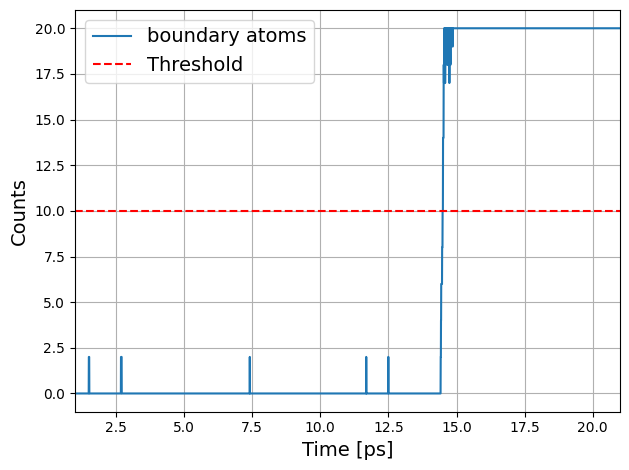

In [25]:
times = np.arange(len(counts)) * 0.001
plt.plot(times[1000:], counts[1000:], label = "boundary atoms")
plt.xlabel("Time [ps]", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.grid()
plt.xlim(times[1000], times[-1])

plt.hlines(10, times[1000], times[-1], colors="red", linestyles="dashed", label="Threshold")

plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("boundary_counts.svg")

In [30]:
nl = NeighborList(cutoffs=[2/2.]*len(traj[0]), skin=1, self_interaction=False, bothways=True)
nl.update(traj[0])
positions = traj[0].get_positions()

In [ ]:
traj[0].get_distance()

In [28]:
for i in range(len(traj[0])):
    print("=====================")
    for j in nl.get_neighbors(i)[0]:
        print(traj[0].get_distance(i, j, mic=True) < 2)

False
False
True
False
False
False
True
False
False
False
False
False
True
False
False
False
False
True
False
True
False
False
False
False
False
True
False
False
True
False
False
False
True
True
False
False
False
False
False
False
False
False
False
True
False
True
False
False
False
False
False
False
False
False
False
True
True
False
False
False
False
True
False
False
False
False
True
False
False
False
False
False
True
False
True
False
False
False
False
True
False
False
False
False
True
False
False
False
False
False
True
False
True
False
False
False
False
False
False
False
False
True
False
True
False
False
False
False
False
False
False
True
True
False
False
False
False
False
False
False
False
True
False
True
False
False
False
False
False
True
False
True
False
False
False
False
False
False
False
True
True
False
False
False
True
False
False
False
False
False
False
True
False
False
False
True
False
True
False
False
False
False
False
False
False
False
False
True
False
False
False
True
False

In [14]:
print(counts)

[np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(100), np.int64(

In [12]:
key = list(results.keys())[0]
entry = results[key]
entry['updates']
entry['counts']

[np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int64(100),
 np.int6

In [6]:
acceptable = [21001, 20001]

keys = list(results.keys())

for key in keys:
    if len(results[key][0]) not in acceptable:
        print(key)
        print(len(results[key][0]))

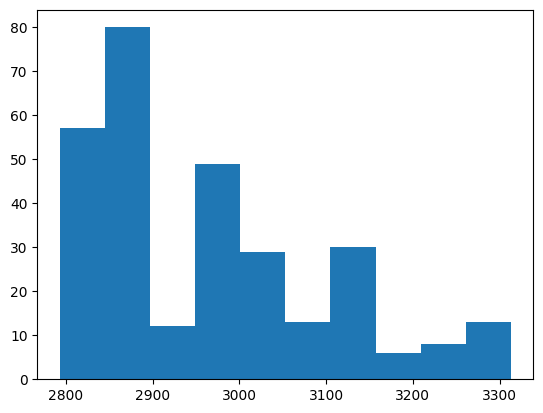

In [7]:
updates = [results[f][1] for f in files]
plt.hist(updates);

In [8]:
traj = Trajectory("/home/gabri/Thesis/PROJECT/KAGGLE_DOWNLOAD/from_C2_v1/TESTING_LAMMPS/strain_stress/5_5/zigzag/300K/LONG/0.19/OUTPUTS_0/DUMP/85.traj")
len(traj)
test = count_boundary_traj(traj, cutoff=2, skin=1, threshold=3)

In [9]:
len(test[0])

21001

In [10]:
results['/home/gabri/Thesis/PROJECT/KAGGLE_DOWNLOAD/from_C2_v1/TESTING_LAMMPS/strain_stress/5_5/zigzag/300K/LONG/0.19/OUTPUTS_0/DUMP/28.traj'][1]

2977

(0.0, 25.0)

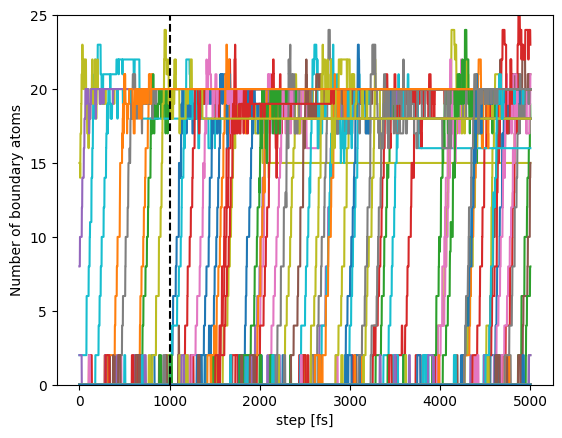

In [7]:
for filename, value in results.items():
    plt.plot(value["counts"], label=filename)

plt.vlines(1000, 0, 100, colors="k", linestyles="dashed", label = "Strain 0.21")
plt.xlabel("step [fs]")
plt.ylabel("Number of boundary atoms")
plt.ylim(0, 25)


In [13]:
import json

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

COUNTSFILE="counts.json"
with open(COUNTSFILE, "w") as f:
    json.dump(results, f, cls=NpEncoder, indent=4)

In [33]:
def custom_subtract(val, normal_len=20001, subtract_lens=[21001], subtract_vals=[1000]):
    if val == normal_len:
        return 0
    
    # Convert to numpy arrays just in case they aren't already
    sub_lens = np.array(subtract_lens)
    sub_vals = np.array(subtract_vals)
    
    # Find the matches
    mask = sub_lens == val
    
    if np.any(mask):
        return sub_vals[mask][0] # Returns the first matching value
    
    return 0 # Default fallback

(array([197.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 100.]),
 array([20001., 20101., 20201., 20301., 20401., 20501., 20601., 20701.,
        20801., 20901., 21001.]),
 <BarContainer object of 10 artists>)

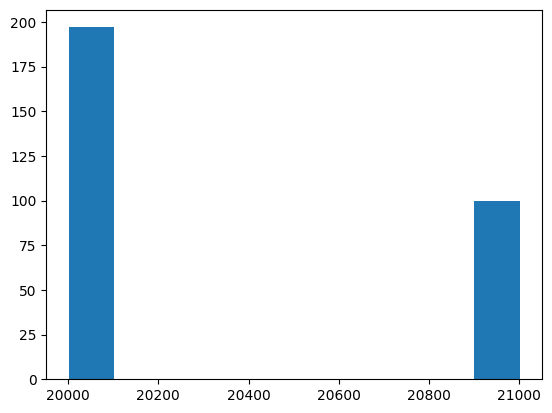

In [37]:
ls = [len(value[0]) for value in results.values()]
plt.hist(ls)

In [40]:
timestep = 0.001

# 1. Vectorize the subtraction lookup
# Assuming custom_subtract is updated to handle arrays, or we map it:
subtract_vals = np.array([custom_subtract(len(v[0])) for v in results.values()])

# 2. Extract breaking steps and handle 'None' cleanly
# Using 'dtype=object' allows us to store 'None' temporarily
raw_steps = np.array([find_breaking_step(v[0]) for v in results.values()], dtype=object)

# 3. Create a boolean mask for valid (not None) steps
# This is cleaner than argwhere because it keeps dimensions flat
is_broken = raw_steps != None

# 4. Filter both arrays simultaneously using the mask
valid_steps = raw_steps[is_broken].astype(float) # Convert to float for math
valid_subtract = subtract_vals[is_broken].astype(float)

# 5. Perform the vectorized math
# (valid_steps - valid_subtract) * timestep
breaking_steps_final = (valid_steps - valid_subtract) * timestep

# Extra: Calculate ncensored from the mask
ncensored = np.sum(~is_broken)

print(f"Censored count: {ncensored}")
print(breaking_steps_final)

Censored count: 218
[17.855  6.237  5.334  7.039  7.664  2.704 17.637 13.384 19.416 16.23
 11.021  5.343 14.436  3.359  7.15  16.618 10.843 17.148 12.329  7.526
 17.666  1.409  1.434 17.13   4.782  1.75   2.492 19.426 12.938  6.332
 16.232  1.954 12.409  9.757 10.377 18.499  4.614  2.901  8.703 10.875
  5.252 13.988  9.061 18.025 10.178  2.963 17.134  5.812  2.823 11.355
  6.495  1.466 19.155  2.13   8.26   9.214 18.148 14.536 10.644  8.443
  5.867 11.331 17.301  7.402 16.808  9.18   8.302  2.896 17.    18.97
 16.632 11.716  9.533  2.314 17.754 10.644  0.089 19.257  5.088]


In [58]:
print(len(breaking_steps_final))

79


In [42]:
import numpy as np
import emcee

# -------------------------------------------------
# Log likelihood for exponential waiting times
# -------------------------------------------------

def log_likelihood(theta, events, nevents, n_censored, Tmax):

    k = theta[0]
    
    T = n_censored * Tmax + np.sum(events)

    return - k * T + nevents*np.log(k)


# -------------------------------------------------
# Prior on rate
# -------------------------------------------------

def log_prior(theta, kmin=1e-12, kmax=1e12):
    k = theta[0]

    if k > 0:
        return -np.log(k)
    
    return -np.inf


def log_posterior(theta, events, nevents, n_censored, Tmax):

    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, events, nevents, n_censored, Tmax)


# -------------------------------------------------
# Run MCMC inference
# -------------------------------------------------

def infer_rate(events, ncensored, Tmax, nwalkers=32, nsteps=10000):

    ndim = 1

    # initial guess from MLE
    k_guess = 1.0 / (Tmax + np.mean(events))

    pos = k_guess * (1 + 1e-2 * np.random.randn(nwalkers, ndim))

    nevents = events.size
    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_posterior,
        args=(events, nevents, ncensored, Tmax)
    )

    sampler.run_mcmc(pos, nsteps, progress=True)

    return sampler


# -------------------------------------------------
# Convert rate samples -> energy barrier samples
# -------------------------------------------------

def rate_to_barrier(k_samples, beta, A):

    DeltaE_samples = -(1/beta) * np.log(k_samples / A)

    return DeltaE_samples


# -------------------------------------------------
# Main analysis function
# -------------------------------------------------

def analyze_transitions(events, ncensored, Tmax, temperature, A):

    kB = 8.617333262e-5  # eV/K
    beta = 1.0 / (kB * temperature)

    sampler = infer_rate(events, ncensored, Tmax)

    burnin = int(0.3 * sampler.iteration)

    samples = sampler.get_chain(discard=burnin, flat=True)

    k_samples = samples[:,0]

    DeltaE_samples = rate_to_barrier(k_samples, beta, A)

    # statistics
    k_mean = np.mean(k_samples)
    k_std = np.std(k_samples)

    E_mean = np.mean(DeltaE_samples)
    E_std = np.std(DeltaE_samples)

    print("Rate k:")
    print(f"mean = {k_mean:.3e}")
    print(f"std  = {k_std:.3e}")

    print("\nEnergy barrier ΔE (eV):")
    print(f"mean = {E_mean:.3f}")
    print(f"std  = {E_std:.3f}")

    return k_samples, DeltaE_samples

In [43]:
ksamples, DeltaE_samples = analyze_transitions(breaking_steps_final, ncensored=ncensored, Tmax=20, temperature=300, A=1e15)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:03<00:00, 2805.50it/s]

Rate k:
mean = 1.533e-02
std  = 1.720e-03

Energy barrier ΔE (eV):
mean = 1.001
std  = 0.003


95% credible interval for k: [0.012, 0.019] eV
Average time to decay: 10.179 ps
Number of decays observed: 79
Rate from average time: 0.098 1/ps


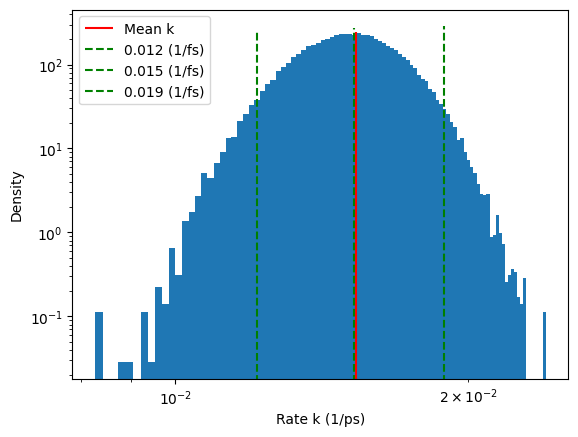

In [48]:
quantiles = np.percentile(ksamples, [2.5, 50, 97.5])
kmean = np.mean(ksamples)
kstd = np.std(ksamples)
Emean = np.mean(DeltaE_samples)
Estd = np.std(DeltaE_samples)
print(f"95% credible interval for k: [{quantiles[0]:.3f}, {quantiles[2]:.3f}] eV")

plt.hist(ksamples, bins=100, density=True)
plt.vlines(np.mean(ksamples), 0, plt.gca().get_ylim()[1], colors="r", label="Mean k")
for q in quantiles:
    plt.vlines(q, 0, plt.gca().get_ylim()[1], colors="g", linestyles="dashed", label=f"{q:.3f} (1/fs)")
plt.xlabel("Rate k (1/ps)")
plt.ylabel("Density")
plt.legend()
plt.xscale("log")
plt.yscale("log")

with open("local_rate_stats.json", "w") as f:
    json.dump({
        "k_mean": kmean,
        "k_std": kstd,
        "E_mean": Emean,
        "E_std": Estd,
    }, f, indent=4)

ndecays = len(breaking_steps_final)
average_time = np.mean(breaking_steps_final)
print(f"Average time to decay: {average_time:.3f} ps")
print(f"Number of decays observed: {ndecays}")
print(f"Rate from average time: {1/average_time:.3f} 1/ps")

In [56]:
ks = np.linspace(0.005, 0.035, num=100000)
lp = [log_posterior([k], breaking_steps_final, len(breaking_steps_final), n_censored=ncensored, Tmax=20) for k in ks]

### A a side note, the posterior probability can be computed analitically

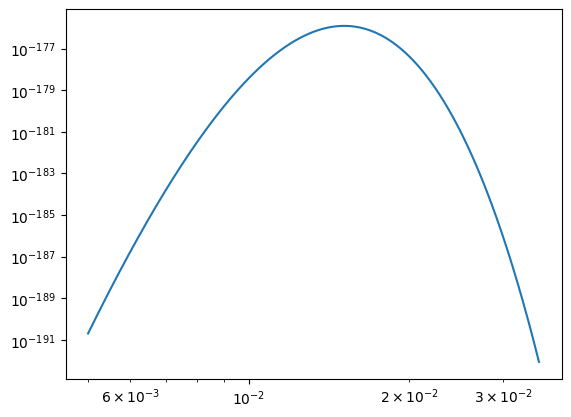

In [57]:
plt.plot(ks, np.exp(lp))
plt.xscale("log")
plt.yscale("log")